In [ ]:
!pip install -U transformers datasets accelerate torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


# Mount Google Drive

The project files and dataset manifests are stored in Google Drive.  
This step mounts the drive so the notebook can access the dataset and configuration files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Add Project Directory to Python Path

The project directory is added to the Python path so that configuration files such as `config.py` can be imported.

In [ ]:
import sys

PROJECT_DIR = "/content/drive/MyDrive/CS7357_Project/data"

sys.path.append(PROJECT_DIR)

print("Project path added.")

Project path added.


# Wav2Vec2 SpecAugment Model Training

This notebook trains a Specaugment dementia speech classification model using the Wav2Vec2 architecture.

The model is trained on deterministic 32 second audio segments constructed from the DementiaNet dataset. Fixed length segmentation reduces shortcut learning from interview structure and recording length artifacts while maintaining reproducibility through deterministic sampling.

The baseline model will be evaluated using accuracy, precision, recall, and macro F1 score.

In [ ]:
import torch
import torchaudio
import pandas as pd
import numpy as np

from datasets import Dataset

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## Load Dataset Manifests

The dataset manifests generated during dataset construction are loaded to define the training, validation, and test splits.

Each manifest contains:

- audio file path
- class label
- speaker identity
- deterministic clip start time
- fixed clip duration

These fields allow the training pipeline to load the correct 32 second segment from each recording.

In [ ]:
from config import *

train_df = pd.read_csv(TRAIN_MANIFEST, sep="\t")
valid_df = pd.read_csv(VALID_MANIFEST, sep="\t")
test_df = pd.read_csv(TEST_MANIFEST, sep="\t")

print("Train samples:", len(train_df))
print("Valid samples:", len(valid_df))
print("Test samples:", len(test_df))

Train samples: 325
Valid samples: 80
Test samples: 38


## Convert Class Labels to Numeric Format

The dataset labels are converted from string values to numeric identifiers.

nodementia = 0  
dementia = 1

This format is required for training classification models using PyTorch and HuggingFace.

In [ ]:
label_map = {
    "nodementia": 0,
    "dementia": 1
}

train_df["label"] = train_df["label"].map(label_map)
valid_df["label"] = valid_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

train_df.head()

,file,label,path,speaker,duration_sec,start_sec,clip_sec,clip_idx
0,alanramsey_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,alanramsey,55.0,0.0,30.0,0
1,alanramsey_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,alanramsey,55.0,20.0,30.0,1
2,georgerobb_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,georgerobb,22.0,0.0,30.0,0
3,andrewsachs_15.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,andrewsachs,90.0,0.0,30.0,0
4,andrewsachs_15.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,andrewsachs,90.0,20.0,30.0,1


## Load Deterministic Audio Segments

Each dataset entry specifies the start time and duration of the audio segment used for training.

This function loads the correct 32 second segment from each recording using the stored metadata fields:

- start_sec
- clip_sec

Extracting fixed length segments ensures consistent input size and prevents models from learning artifacts related to recording length.

In [ ]:
def load_audio_segment(row):

    path = row["path"]
    start = row["start_sec"]
    clip = row["clip_sec"]

    sr = 16000  # DementiaBank recordings are 16kHz

    frame_offset = int(start * sr)
    num_frames = int(clip * sr)

    waveform, _ = torchaudio.load(
        path,
        frame_offset=frame_offset,
        num_frames=num_frames
    )

    waveform = waveform.squeeze().numpy()

    return waveform

## Convert DataFrames to HuggingFace Dataset Format

The dataset manifests are converted from pandas DataFrames into HuggingFace Dataset objects.

The HuggingFace dataset format allows efficient preprocessing, batching, and integration with the Transformers training pipeline.

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 325
})
Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 80
})
Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 38
})


**Hugging Face Log in**

In [ ]:
from huggingface_hub import login

login()

## Load Wav2Vec2 Feature Processor

The Wav2Vec2 processor converts raw audio waveforms into normalized input features compatible with the pretrained model.

The baseline experiment uses the standard `facebook/wav2vec2-base` processor.

In [ ]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

## Audio Preprocessing Function

This function performs the preprocessing required before training.

For each dataset sample it:

1. Loads the deterministic 30 second audio segment.
2. Converts the waveform into Wav2Vec2 input features.
3. Assigns the numeric label used during training.

In [ ]:
def preprocess(batch):

    audio = load_audio_segment(batch)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    batch["input_values"] = inputs.input_values[0]
    batch["labels"] = batch["label"]

    return batch

## Apply Audio Preprocessing

The preprocessing function is applied to all dataset splits to convert raw audio segments into Wav2Vec2 model inputs.

In [ ]:
train_dataset = train_dataset.map(preprocess)
valid_dataset = valid_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

## Load Wav2Vec2 Classification Model

The baseline classifier uses the pretrained `facebook/wav2vec2-base` model with a classification head for binary prediction.

The model outputs probabilities for:

0 → non dementia  
1 → dementia

In [ ]:

from transformers import AutoConfig, Wav2Vec2ForSequenceClassification

label2id = {"nodementia": 0, "dementia": 1}
id2label = {0: "nodementia", 1: "dementia"}

config = AutoConfig.from_pretrained("facebook/wav2vec2-base")

config.num_labels = 2
config.label2id = label2id
config.id2label = id2label

# keep same dropout values used in baseline
config.attention_dropout = 0.1
config.hidden_dropout = 0.1
config.feat_proj_dropout = 0.1
config.final_dropout = 0.2

# SpecAugment settings
config.apply_spec_augment = True
config.mask_time_prob = 0.08
config.mask_time_length = 10
config.mask_time_min_masks = 2

config.mask_feature_prob = 0.02
config.mask_feature_length = 8
config.mask_feature_min_masks = 1

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    config=config,
    ignore_mismatched_sizes=True
)

model.freeze_feature_encoder()

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_dataset["labels"]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

## Training Configuration

Training parameters define how the model will be optimized during training.

Key settings include learning rate, batch size, number of epochs, and evaluation frequency.

In [ ]:
training_args = TrainingArguments(
    output_dir="./baseline_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=22,
    logging_steps=10,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    load_best_model_at_end=True,
    push_to_hub=True,
    hub_model_id="Mrsmetamorphosis/dementia-wav2vec-scientific-specaugment-V2"
)

In [ ]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        class_weights = torch.tensor([1.32, 0.8045]).to(model.device)

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

**Push the model to Hugging Face Hub**

## Evaluation Metrics

Model performance is evaluated using accuracy, precision, recall, and macro F1 score.

Macro F1 is used as the primary metric because it balances performance across both classes.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):

    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    precision_class, recall_class, f1_class, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_nodementia": f1_class[0],
        "f1_dementia": f1_class[1]
    }

## Dynamic Batch Padding

Some recordings are shorter than the full 32 second target window. As a result, waveform lengths can vary across samples.

This custom data collator pads the input waveforms dynamically within each batch so they can be stacked into tensors for model training.


In [ ]:
def data_collator(features):
    input_features = [{"input_values": f["input_values"]} for f in features]
    label_features = [f["labels"] for f in features]

    batch = processor.pad(
        input_features,
        padding=True,
        return_tensors="pt"
    )

    batch["labels"] = torch.tensor(label_features, dtype=torch.long)
    return batch

## Initialize Trainer

The HuggingFace Trainer manages the training loop, evaluation, and logging for the model.

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
import collections

collections.Counter(train_dataset["labels"])
collections.Counter(valid_dataset["labels"])
collections.Counter(test_dataset["labels"])

Counter({1: 14, 0: 24})

## Train SpecAugment Model

The model is trained on the training dataset and evaluated on the validation set at the end of each epoch.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,F1 Nodementia,F1 Dementia
1,0.661990,0.686072,0.562500,0.406654,0.437063,0.612554,0.516414,0.102564,0.710744
2,0.507482,0.701701,0.562500,0.406654,0.437063,0.612554,0.516414,0.102564,0.710744
3,0.583374,0.796024,0.575000,0.505455,0.524000,0.573593,0.542929,0.320000,0.690909
4,0.691131,1.022609,0.550000,0.547454,0.544060,0.566667,0.563131,0.581395,0.513514
5,0.463516,0.833618,0.587500,0.587436,0.587951,0.591766,0.592172,0.582278,0.592593
6,0.640089,1.163883,0.587500,0.458906,0.485284,0.686667,0.544192,0.195122,0.722689
7,0.286760,1.220274,0.625000,0.613153,0.619923,0.620000,0.613636,0.545455,0.680851
8,0.460330,1.145356,0.662500,0.602868,0.618257,0.736510,0.630051,0.448980,0.756757
9,0.161013,1.253356,0.675000,0.674185,0.675815,0.675000,0.676768,0.657895,0.690476
10,0.252355,1.355075,0.650000,0.644444,0.648889,0.645780,0.643939,0.600000,0.688889


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1804, training_loss=0.23799138220528887, metrics={'train_runtime': 2625.9454, 'train_samples_per_second': 2.723, 'train_steps_per_second': 0.687, 'total_flos': 1.94736670128e+18, 'train_loss': 0.23799138220528887, 'epoch': 22.0})

In [ ]:
collections.Counter(train_dataset["labels"])

Counter({1: 202, 0: 123})

In [ ]:
preds = trainer.predict(test_dataset)

import numpy as np
print(np.unique(np.argmax(preds.predictions, axis=1), return_counts=True))

(array([0, 1]), array([20, 18]))


In [ ]:
print("Train labels:", set(train_dataset["labels"]))
print("Validation labels:", set(valid_dataset["labels"]))
print("Test labels:", set(test_dataset["labels"]))

Train labels: {0, 1}
Validation labels: {0, 1}
Test labels: {0, 1}


In [ ]:
from collections import Counter

print("Train distribution:", Counter(train_dataset["labels"]))
print("Validation distribution:", Counter(valid_dataset["labels"]))
print("Test distribution:", Counter(test_dataset["labels"]))

Train distribution: Counter({1: 202, 0: 123})
Validation distribution: Counter({1: 44, 0: 36})
Test distribution: Counter({0: 24, 1: 14})


In [ ]:
pred = trainer.predict(test_dataset)

print(pred.metrics)

{'test_loss': 1.6926072835922241, 'test_accuracy': 0.5789473684210527, 'test_f1_macro': 0.5681818181818181, 'test_f1_weighted': 0.5861244019138756, 'test_precision_macro': 0.5722222222222222, 'test_recall_macro': 0.5773809523809523, 'test_f1_nodementia': 0.6363636363636364, 'test_f1_dementia': 0.5, 'test_runtime': 8.8708, 'test_samples_per_second': 4.284, 'test_steps_per_second': 1.127}


## Evaluate Model on Test Dataset

After training completes, the model is evaluated on the held out test dataset.

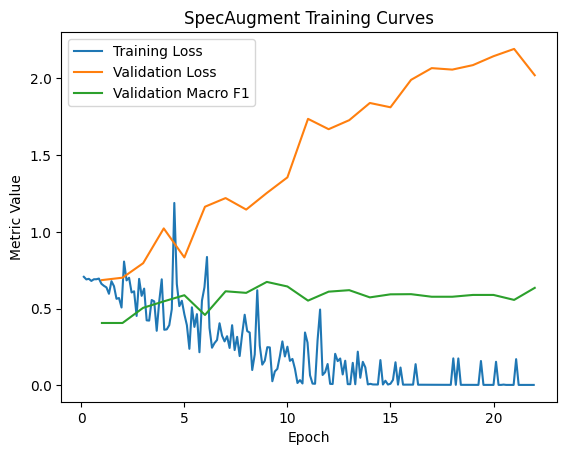

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Extract trainer logs
logs = pd.DataFrame(trainer.state.log_history)

# Keep only rows with epoch values
logs = logs[logs["epoch"].notna()]

# Separate training and validation metrics
train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]
val_loss = logs[logs["eval_loss"].notna()][["epoch", "eval_loss"]]
val_f1 = logs[logs["eval_f1_macro"].notna()][["epoch", "eval_f1_macro"]]

plt.figure()

plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Validation Loss")
plt.plot(val_f1["epoch"], val_f1["eval_f1_macro"], label="Validation Macro F1")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("SpecAugment Training Curves")
plt.legend()
plt.show()

In [ ]:
plt.savefig("baseline_training_curves.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="macro"
)

accuracy = accuracy_score(labels, preds)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)

ValueError: Found input variables with inconsistent numbers of samples: [325, 3]

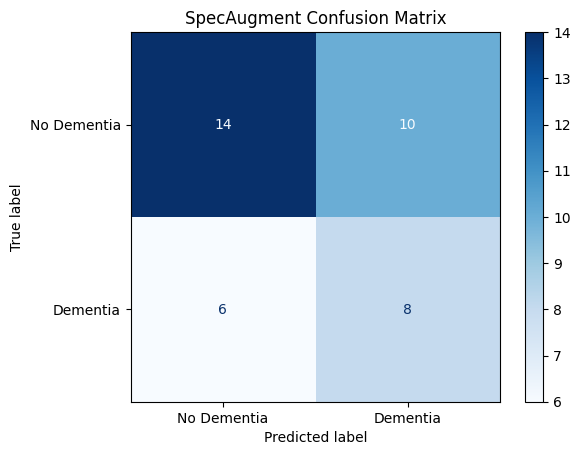

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

pred = trainer.predict(test_dataset)

preds = np.argmax(pred.predictions, axis=1)
labels = pred.label_ids

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Dementia", "Dementia"]
)

disp.plot(cmap="Blues")

plt.title("SpecAugment Confusion Matrix")
plt.show()

In [ ]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e_model/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...e_model/model.safetensors:  11%|#         | 40.0MB /  378MB            

CommitInfo(commit_url='https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-specaugment-V2/commit/136d804fb95d5cb4ee8bf5260acf643fe1e86aab', commit_message='End of training', commit_description='', oid='136d804fb95d5cb4ee8bf5260acf643fe1e86aab', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-specaugment-V2', endpoint='https://huggingface.co', repo_type='model', repo_id='Mrsmetamorphosis/dementia-wav2vec-scientific-specaugment-V2'), pr_revision=None, pr_num=None)

In [ ]:
pred = trainer.predict(test_dataset)

eval_results = pred.metrics
print(eval_results)

{'test_loss': 1.6926072835922241, 'test_accuracy': 0.5789473684210527, 'test_f1_macro': 0.5681818181818181, 'test_f1_weighted': 0.5861244019138756, 'test_precision_macro': 0.5722222222222222, 'test_recall_macro': 0.5773809523809523, 'test_f1_nodementia': 0.6363636363636364, 'test_f1_dementia': 0.5, 'test_runtime': 8.9967, 'test_samples_per_second': 4.224, 'test_steps_per_second': 1.112}


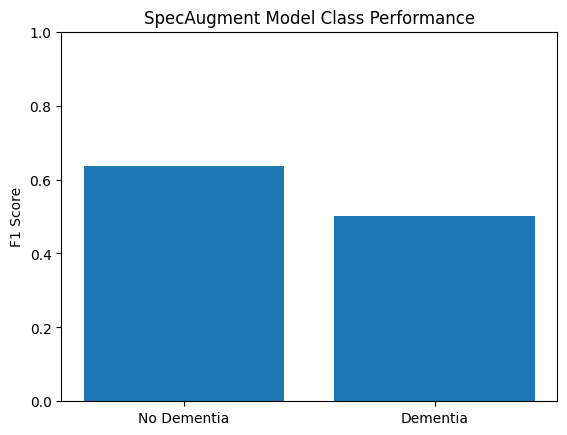

In [ ]:

import matplotlib.pyplot as plt

f1_scores = [
    eval_results["test_f1_nodementia"],
    eval_results["test_f1_dementia"]
]

labels = ["No Dementia", "Dementia"]

plt.figure()
plt.bar(labels, f1_scores)

plt.title("SpecAugment Model Class Performance")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.show()

In [ ]:
processor.push_to_hub("Mrsmetamorphosis/dementia-wav2vec-scientific-specaugment-V2")